In [284]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Overview

In [188]:
df = pd.read_csv("./dataset/dirty_cafe_sales.csv", na_values=["UNKNOWN", "ERROR"])

print("-"*32, "[ Shape ]")
print(f"Shape = {df.shape}")

print("-"*32, "[ The first five ]")
display(df.head())

print("-"*32, "[ General information ]")
print(df.info())

print("-"*32, "[ Some properties ]")
display(df.describe())

-------------------------------- [ Shape ]
Shape = (10000, 8)
-------------------------------- [ The first five ]


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


-------------------------------- [ General information ]
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  str    
 1   Item              9031 non-null   str    
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    6822 non-null   str    
 6   Location          6039 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB
None
-------------------------------- [ Some properties ]


,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9498.000000
mean,3.028463,2.949984,8.924352
std,1.419007,1.278450,6.009919
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


## Null Values

In [189]:
null_counts = df.isna().sum()
display(null_counts)

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [190]:
rows_with_null = df[df.isna().any(axis=1)]
display(rows_with_null)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,NaN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02


## Data Type Conversion

In [191]:
df["Quantity"] = df["Quantity"].astype("float")
df["Price Per Unit"] = df["Price Per Unit"].astype("float")
df["Total Spent"] = df["Total Spent"].astype("float")

## Column specific detailed insight

### Item

In [192]:
col_item = df["Item"]

In [193]:
col_item.unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',        nan,
 'Sandwich',    'Juice',      'Tea']
Length: 9, dtype: str

In [194]:
col_item.value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

### Quantity

In [195]:
col_quantity = df["Quantity"]

In [196]:
col_quantity.unique()

array([ 2.,  4.,  5.,  3.,  1., nan])

In [197]:
col_quantity.value_counts()

Quantity
5.0    2013
2.0    1974
4.0    1863
3.0    1849
1.0    1822
Name: count, dtype: int64

### Price Per Unit

In [198]:
col_price = df["Price Per Unit"]

In [199]:
col_price.unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

`value_counts` is useless in the case of this dataset because of the abundant occurrence of null values. Instead, `unique` is enough just to know what unique values we have.

### Total Spent

`Total Spent` is just the product of `Quantity` and `Price Per Unit` which doesn't give us any new insight (redundant).

But let's just check if there exists a case where `Total Spent` is null while the `Quantity` and `Price Per Unit` have valid values. Why do this? We can know there are cases where the cashier were not able to calculate the product properly.

Do this while targeting the two columns too because in doing so, if there exist such cases, we can deduce for example the value for `Quantity` from the rest columns.

In [200]:
col_total = df["Total Spent"]

In [201]:
col_total.unique()

array([ 4. , 12. ,  nan, 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,
        3. ,  6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [202]:
col_total_na_count = len(df[col_total.isna()]["Total Spent"])
print(f"NaN count of original Total Spent column: {col_total_na_count}")

NaN count of original Total Spent column: 502


In [203]:
valid_quantity = col_quantity.notna()
valid_price = col_price.notna()
valid_total = col_total.notna()

invalid_quantity = col_quantity.isna()
invalid_price = col_price.isna()
invalid_total = col_total.isna()

In [ ]:
mask_invalid_total = valid_quantity & valid_price & invalid_total
df.loc[mask_invalid_total, "Total Spent"] = (df.loc[mask_invalid_total, "Quantity"] * df.loc[mask_invalid_total, "Price Per Unit"])

In [208]:
len(df[df["Total Spent"].isna()]["Total Spent"])

40

With our previous initiation, we managed to cover up **502 - 40 = 462 NaN values** for the `Total Spent` column. Let's now try to deduce NaN values for `Quantity` and `Price Per Unit`

In [209]:
valid_quantity = col_quantity.notna()
valid_price = col_price.notna()
valid_total = col_total.notna()

invalid_quantity = col_quantity.isna()
invalid_price = col_price.isna()
invalid_total = col_total.isna()

In [ ]:
col_quantity_na_count = len(df[col_quantity.isna()]["Quantity"])
print(f"NaN count of original Quantity column: {col_quantity_na_count}")

NaN count of original Quantity Spent column: 479


In [213]:
mask_invalid_quantity = invalid_quantity & valid_price & valid_total
df.loc[mask_invalid_quantity, "Quantity"] = (
    df[mask_invalid_quantity]["Total Spent"]) / (
    df[mask_invalid_quantity]["Price Per Unit"])

In [215]:
len(df[df["Quantity"].isna()]["Quantity"])

38

`Quantity`'s initial **479** NaN values are now reduced to **38**.

In [216]:
valid_quantity = col_quantity.notna()
valid_price = col_price.notna()
valid_total = col_total.notna()

invalid_quantity = col_quantity.isna()
invalid_price = col_price.isna()
invalid_total = col_total.isna()

In [217]:
col_price_na_count = len(df[col_price.isna()]["Price Per Unit"])
print(f"NaN count of original Price Per Unit column: {col_price_na_count}")

NaN count of original Price Per Unit column: 533


In [218]:
mask_invalid_price = valid_quantity & invalid_price & valid_total
df.loc[mask_invalid_price, "Price Per Unit"] = (
    df[mask_invalid_price]["Total Spent"]) / (
    df[mask_invalid_price]["Quantity"])

In [221]:
len(df[df["Price Per Unit"].isna()]["Price Per Unit"])

38

`Price Per Unit`'s initial **533** NaN values are now reduced to **38**.

In [ ]:
# df_either_nan = df[df[["Quantity", "Price Per Unit"]].isna().any(axis=1)]
# print(len(df_either_nan))
# both_nan_count = df[["Quantity", "Price Per Unit"]].isna().all(axis=1).sum()
# print(both_nan_count)
# display(df_either_nan[["Quantity", "Price Per Unit", "Total Spent"]])

### Payment Method

In [236]:
col_payment = df["Payment Method"]

In [237]:
col_payment.unique()

<StringArray>
['Credit Card', 'Cash', nan, 'Digital Wallet']
Length: 4, dtype: str

In [243]:
print("Payment isna", col_payment.isna().sum())
print("Payment notna", col_payment.notna().sum())

Payment isna 3178
Payment notna 6822


### Location

In [244]:
col_location = df["Location"]

In [245]:
col_location.unique()

<StringArray>
['Takeaway', 'In-store', nan]
Length: 3, dtype: str

In [246]:
col_location.value_counts()

Location
Takeaway    3022
In-store    3017
Name: count, dtype: int64

### Transaction Date

In [ ]:
col_date = df["Transaction Date"]
date_counts = col_date.value_counts().sort_index()

In [273]:
min_transaction_per_day = date_counts.min()
max_transaction_per_day = date_counts.max()
median = date_counts.median()

print(f"Minimum transaction in a day = {min_transaction_per_day}")
print(f"Maximum transaction in a day = {max_transaction_per_day}")
print(f"Average (median) sales in a day = {median}")

Minimum transaction in a day = 14
Maximum transaction in a day = 40
Average (median) sales in a day = 26.0


In [281]:
print(date_counts[date_counts.eq(min_transaction_per_day)])
print(date_counts[date_counts.eq(max_transaction_per_day)])

Transaction Date
2023-02-17    14
2023-03-11    14
2023-07-22    14
Name: count, dtype: int64
Transaction Date
2023-02-06    40
2023-06-16    40
Name: count, dtype: int64


## Analysis

### Progression of sales

Lemme plot a graph with x-axis transaction dates, and y-axis with sales count.

In [301]:
date_counts.index = pd.to_datetime(date_counts.index)
monthly_counts = date_counts.groupby(date_counts.index.to_period("M")).sum()
monthly_counts.index = monthly_counts.index.strftime("%b")
display(monthly_counts)

Transaction Date
Jan    818
Feb    727
Mar    827
Apr    774
May    777
Jun    818
Jul    791
Aug    803
Sep    788
Oct    838
Nov    784
Dec    795
Name: count, dtype: int64

In [311]:
min_sales_per_month = monthly_counts.min()
max_sales_per_month = monthly_counts.max()

In [319]:
print(monthly_counts[monthly_counts.eq(min_sales_per_month)])
print(monthly_counts[monthly_counts.eq(max_sales_per_month)])
print(f"Range = {max_sales_per_month - min_sales_per_month}")
print(f"Standard Deviation = {monthly_counts.values.std()}")

Transaction Date
Feb    727
Name: count, dtype: int64
Transaction Date
Oct    838
Name: count, dtype: int64
Range = 111
Standard Deviation = 28.240042492885877


In [302]:
x_values = monthly_counts.index
y_values = monthly_counts.values

print(x_values)
print(y_values)

Index(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
       'Nov', 'Dec'],
      dtype='str', name='Transaction Date')
[818 727 827 774 777 818 791 803 788 838 784 795]


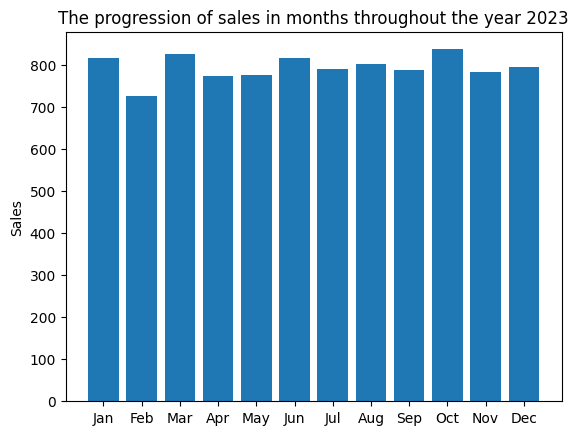

In [318]:
plt.bar(x_values, y_values)
plt.title("The progression of sales in months throughout the year 2023")
plt.ylabel("Sales")
plt.show()